In [578]:
# Import the dataset 
import pandas as pd
df = pd.read_csv("C:\\Users\\user\\Desktop\\Vani_Linear_Regression\\Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [579]:
# display the first five records.
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [580]:
# Print the shape 
df.shape

(7500, 16)

In [581]:
# column data types of the dataset. 
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

In [582]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [583]:
# Identify numerical and categorical features present in the dataset. 
df.dtypes

transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object

In [584]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'addicted_label']
Categorical Features: ['transaction_id', 'user_id', 'gender', 'stress_level', 'academic_work_impact', 'addiction_level']


In [585]:
#  Check for missing values 
df.isnull().sum()


transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [586]:
# handle missing value of addiction level.
df['addiction_level']=df['addiction_level'].fillna('Moderate')
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Moderate,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Moderate,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,Moderate,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [587]:
#  Identify and remove duplicate records if any.
df.duplicated().sum()

np.int64(0)

In [588]:
                                     # --------------------------Convert categorical variables into numerical format using suitable encoding techniques.---------------------#

In [589]:
df['gender']=df['gender'].replace({
    'Male': 1,
    'Female':0,
    'Other': 2
})
df

C:\Users\user\AppData\Local\Temp\ipykernel_4004\1919618556.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender']=df['gender'].replace({


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,1,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Moderate,0
1,TXN00002,U00002,24,2,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Moderate,0
2,TXN00003,U00003,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,2,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,1,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,Moderate,0
7497,TXN07498,U07498,22,0,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,1,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [590]:
df['stress_level']=df['stress_level'].replace({
    'Low': 0,
    'Medium':1,
    'High': 2
})
df

C:\Users\user\AppData\Local\Temp\ipykernel_4004\2204531672.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['stress_level']=df['stress_level'].replace({


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,1,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,Yes,Moderate,0
1,TXN00002,U00002,24,2,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,Yes,Moderate,0
2,TXN00003,U00003,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,No,Mild,0
3,TXN00004,U00004,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,Yes,Moderate,1
4,TXN00005,U00005,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,2,9.85,1.75,3.13,3.49,5.81,249,122,11.99,0,Yes,Moderate,1
7496,TXN07497,U07497,35,1,5.67,2.33,2.76,5.90,8.47,197,56,7.08,0,No,Moderate,0
7497,TXN07498,U07498,22,0,9.99,3.61,1.09,1.16,8.17,207,24,12.84,1,Yes,Severe,1
7498,TXN07499,U07499,23,1,8.74,1.59,0.07,4.64,6.19,134,62,10.52,2,Yes,Severe,1


In [591]:
df['academic_work_impact']=df['academic_work_impact'].replace({
    'No': 0,
    'Yes':1,
})
df

C:\Users\user\AppData\Local\Temp\ipykernel_4004\1386400107.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['academic_work_impact']=df['academic_work_impact'].replace({


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,1,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,Moderate,0
1,TXN00002,U00002,24,2,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,Moderate,0
2,TXN00003,U00003,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,Mild,0
3,TXN00004,U00004,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,Moderate,1
4,TXN00005,U00005,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,2,9.85,1.75,3.13,3.49,5.81,249,122,11.99,0,1,Moderate,1
7496,TXN07497,U07497,35,1,5.67,2.33,2.76,5.90,8.47,197,56,7.08,0,0,Moderate,0
7497,TXN07498,U07498,22,0,9.99,3.61,1.09,1.16,8.17,207,24,12.84,1,1,Severe,1
7498,TXN07499,U07499,23,1,8.74,1.59,0.07,4.64,6.19,134,62,10.52,2,1,Severe,1


In [592]:
df['addiction_level']=df['addiction_level'].replace({
    'Mild': 0,
    'Moderate':1,
    'Severe': 2
})
df

C:\Users\user\AppData\Local\Temp\ipykernel_4004\662330516.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['addiction_level']=df['addiction_level'].replace({


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,1,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,1,0
1,TXN00002,U00002,24,2,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,1,0
2,TXN00003,U00003,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,0,0
3,TXN00004,U00004,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,1,1
4,TXN00005,U00005,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,2,9.85,1.75,3.13,3.49,5.81,249,122,11.99,0,1,1,1
7496,TXN07497,U07497,35,1,5.67,2.33,2.76,5.90,8.47,197,56,7.08,0,0,1,0
7497,TXN07498,U07498,22,0,9.99,3.61,1.09,1.16,8.17,207,24,12.84,1,1,2,1
7498,TXN07499,U07499,23,1,8.74,1.59,0.07,4.64,6.19,134,62,10.52,2,1,2,1


In [593]:
# drop the cloumns transaction_id and user_id
df.drop(['user_id'],axis=1,inplace=True)
df.drop(['transaction_id'],axis=1,inplace=True)
df


,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,21,1,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,1,0
1,24,2,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,1,0
2,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,0,0
3,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,1,1
4,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,26,2,9.85,1.75,3.13,3.49,5.81,249,122,11.99,0,1,1,1
7496,35,1,5.67,2.33,2.76,5.90,8.47,197,56,7.08,0,0,1,0
7497,22,0,9.99,3.61,1.09,1.16,8.17,207,24,12.84,1,1,2,1
7498,23,1,8.74,1.59,0.07,4.64,6.19,134,62,10.52,2,1,2,1


In [594]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\user\AppData\Local\Temp\ipykernel_4004\2851567810.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='age', y = 'daily_screen_time_hours', palette='viridis')


<Axes: xlabel='age', ylabel='daily_screen_time_hours'>

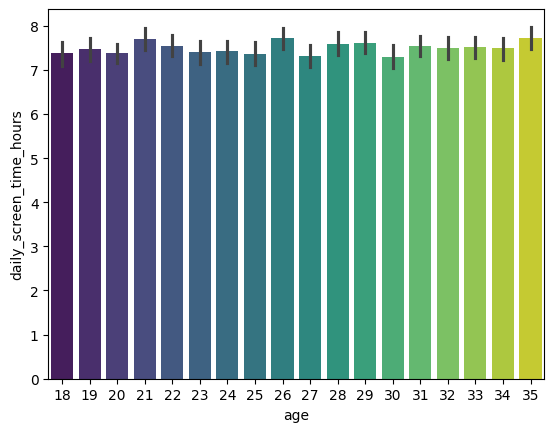

In [595]:
sns.barplot(data=df,x='age', y = 'daily_screen_time_hours', palette='viridis')

C:\Users\user\AppData\Local\Temp\ipykernel_4004\116347698.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df,x='age', y = 'daily_screen_time_hours', palette='viridis')


<Axes: xlabel='age', ylabel='daily_screen_time_hours'>

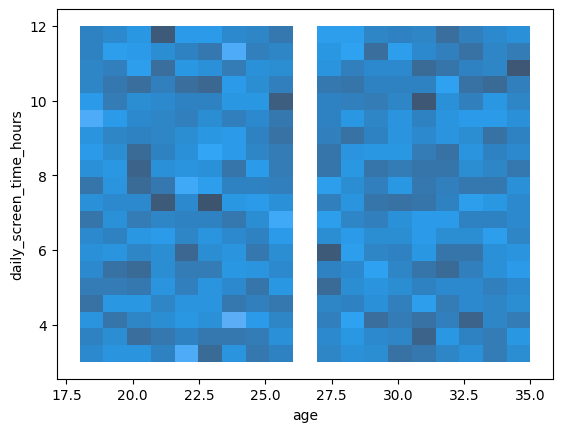

In [596]:
sns.histplot(data=df,x='age', y = 'daily_screen_time_hours', palette='viridis')

In [597]:
#  Analyze the relationship between daily screen time and addiction, and sleep hours and addiction.
df[['daily_screen_time_hours','addiction_level']].corr()

,daily_screen_time_hours,addiction_level
daily_screen_time_hours,1.00000,0.39422
addiction_level,0.39422,1.00000


In [598]:
# Examine the impact of gender, stress level, and academic/work impact on addiction behavior.
df[['gender','stress_level']].corr()

,gender,stress_level
gender,1.000000,0.022342
stress_level,0.022342,1.000000


In [599]:
df[['academic_work_impact','addiction_level']].corr()

,academic_work_impact,addiction_level
academic_work_impact,1.000000,-0.008812
addiction_level,-0.008812,1.000000


In [600]:
# Compute the correlation matrix for numerical features. b) Identify the features most strongly related to addiction and interpret the results.

df1 = df[['age', 'gender', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label']].corr()

<Axes: >

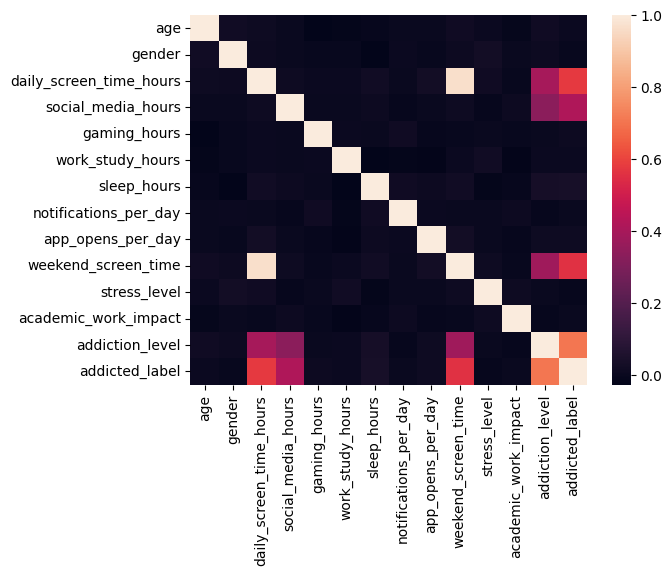

In [601]:
sns.heatmap(df1)

In [602]:
X = df[['age', 'gender', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level']]

y = df['addicted_label']

In [603]:
X 

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level
0,21,1,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,1
1,24,2,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,1
2,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,0
3,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,1
4,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,26,2,9.85,1.75,3.13,3.49,5.81,249,122,11.99,0,1,1
7496,35,1,5.67,2.33,2.76,5.90,8.47,197,56,7.08,0,0,1
7497,22,0,9.99,3.61,1.09,1.16,8.17,207,24,12.84,1,1,2
7498,23,1,8.74,1.59,0.07,4.64,6.19,134,62,10.52,2,1,2


In [604]:
y

0       0
1       0
2       0
3       1
4       1
       ..
7495    1
7496    0
7497    1
7498    1
7499    1
Name: addicted_label, Length: 7500, dtype: int64

In [605]:
from sklearn.model_selection import train_test_split

In [606]:
X_train,X_test,y_train,y_test = train_test_split(X,y)

In [607]:
from sklearn.preprocessing import StandardScaler

In [608]:
model = StandardScaler()
model.fit_transform

<bound method TransformerMixin.fit_transform of StandardScaler()>

In [609]:
from sklearn.linear_model import LogisticRegression

In [610]:
model = LogisticRegression()
model.fit(X_train, y_train)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [611]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 0, 1], shape=(1875,))

In [612]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [613]:
accuracy_score(y_test,y_pred)

0.9429333333333333

In [614]:
precision_score(y_test,y_pred)

0.9552785923753666

In [615]:
recall_score(y_test,y_pred)

0.9659006671608599

In [616]:
f1_score(y_test,y_pred)

0.9605602653888684

In [617]:
confusion_matrix(y_test,y_pred)

array([[ 465,   61],
       [  46, 1303]])